<a href="https://colab.research.google.com/github/nalinis07/APT_Ref_Copy_Links/blob/MASTER/Nals_Lesson_62_Reference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 62: Multiple Linear Regression - Introduction

**WARNING:** The reference notebook is meant **ONLY** for a teacher. Please **DON'T** share it with any student.

The contents of the reference notebook are meant only to prepare a teacher for a class. To conduct the class, use the class copy of the reference notebook. The link and the instructions for the same are provided in the **Notes To The Teacher** section.

|Particulars|Description|
|-|-|
|**Topic**|Multiple Linear Regression - Introduction|
|||
|**Class Description**|A student learns to build a multiple linear regression model using `sklearn` and `statsmodels.api` module|
|||
|**Class**|C62|
|||
|**Class Time**|45 minutes|
|||
|**Goal**|Build a multiple linear regression model using `sklearn` and `statsmodels.api` module|
|||
|**Teacher Resources**|Google Account|
||Laptop with internet connectivity|
||Earphones with mic|
|||
|**Student Resources**|Google Account|
||Laptop with internet connectivity|
||Earphones with mic|


---

### Warm-up Quiz

```
TEACHER
I have an exciting quiz question for you! Are you ready to answer this question?

EXPECTED STUDENT RESPONSE
Yes.
```

**Instructions for the Teacher:**
- Please click on the "Quiz Time" button on the bottom right corner of your screen to start the In-Class Quiz. <img src='https://student-datasets-bucket.s3.ap-south-1.amazonaws.com/images/quiz-time.png' width = 150>

- A quiz will be visible to both you and the student. Encourage the student to answer the quiz question.

- The student may choose the wrong option, help the student to think correctly about the question and then answer again.

- After the student selects the correct option, the "End Quiz" button will start appearing on your screen. <img src='https://student-datasets-bucket.s3.ap-south-1.amazonaws.com/images/end-quiz.png' width = 150>  

- Click the "End quiz" button to close the quiz pop-up and continue the class.
  
- Do not spend more than 2 minutes on this quiz.

---

### Teacher-Student Activities

In the last class, we discussed that we need to build a multiple linear regression model to accurately predict the relative humidity values. The linear regression equation considered is

$$\text{RH} = \beta_0 + \beta_1 \space{} \text{CO} + \beta_2 \space{} \text{C}_6 \text{H}_6 + \beta_3 \space{} \text{NMHC} + \beta_4 \space{} \text{NO}_x + \beta_5 \space{} \text{NO}_2 + \beta_6 \space{} \text{O}_3 + \beta_7 \space{} \text{T} + \beta_8 \space{} \text{AH} + \beta_9 \space{} \text{year} + \beta_{10} \space{} \text{month} + \beta_{11} \space{} \text{day} + \epsilon$$

In this class, we will estimate the values of these coefficients and find out which columns are least significant by referring to their p-values.



---

In [2]:
# Run the code cell.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Loading the dataset.
csv_file = 'https://s3-student-datasets-bucket.whjr.online/whitehat-ds-datasets/air-quality/AirQualityUCI.csv'
df = pd.read_csv(csv_file, sep=';')

# Dropping the 'Unnamed: 15' & 'Unnamed: 16' columns.
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], axis=1)

# Dropping the null values.
df = df.dropna()

# Creating a Pandas series containing 'datetime' objects.
dt_series = pd.Series(data = [item.split("/")[2] + "-" + item.split("/")[1] + "-" + item.split("/")[0] for item in df['Date']], index=df.index) + ' ' + pd.Series(data=[str(item).replace(".", ":") for item in df['Time']], index=df.index)
dt_series = pd.to_datetime(dt_series)

# Remove the Date & Time columns from the DataFrame and insert the 'dt_series' in it.
df = df.drop(columns=['Date', 'Time'], axis=1)
df.insert(loc=0, column='DateTime', value=dt_series)

# Get the Pandas series containing the year values as integers.
year_series = dt_series.dt.year

# Get the Pandas series containing the month values as integers.
month_series = dt_series.dt.month

# Get the Pandas series containing the day values as integers.
day_series = dt_series.dt.day

# Get the Pandas series containing the days of a week, i.e., Monday, Tuesday, Wednesday etc.
day_name_series = dt_series.dt.day_name()

# Add the 'Year', 'Month', 'Day' and 'Day Name' columns to the DataFrame.
df['Year'] = year_series
df['Month'] = month_series
df['Day'] = day_series
df['Day Name'] = day_name_series

# Sort the DataFrame by the 'DateTime' values in the ascending order. Also, display the first 10 rows of the DataFrame.
df = df.sort_values(by='DateTime')

# Create a function to replace the commas with periods in a Pandas series.
def comma_to_period(series):
    new_series = pd.Series(data=[float(str(item).replace(',', '.')) for item in series], index=df.index)
    return new_series

# Apply the 'comma_to_period()' function on the ''CO(GT)', 'C6H6(GT)', 'T', 'RH' and 'AH' columns.
cols_to_correct = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH'] # Create a list of column names.
for col in cols_to_correct: # Iterate through each column
    df[col] = comma_to_period(df[col]) # Replace the original column with the new series.

# Remove all the columns from the 'df' DataFrame containing more than 10% garbage value.
df = df.drop(columns=['NMHC(GT)', 'CO(GT)', 'NOx(GT)', 'NO2(GT)'], axis=1)

# Create a new DataFrame containing records for the years 2004 and 2005.
aq_2004_df = df[df['Year'] == 2004]
aq_2005_df = df[df['Year'] == 2005]

# Replace the -200 value with the median values for each column having indices between 1 and -4 (excluding -4) for the 2004 year DataFrame.
for col in aq_2004_df.columns[1:-4]:
  median = aq_2004_df.loc[aq_2004_df[col] != -200, col].median()
  aq_2004_df[col] = aq_2004_df[col].replace(to_replace=-200, value=median)

# Repeat the same exercise for the 2005 year DataFrame.
for col in aq_2005_df.columns[1:-4]:
  median = aq_2005_df.loc[aq_2005_df[col] != -200, col].median()
  aq_2005_df[col] = aq_2005_df[col].replace(to_replace=-200, value=median)

# Group the DataFrames about the 'Month' column.
group_2004_month = aq_2004_df.groupby(by='Month')
group_2005_month = aq_2005_df.groupby(by='Month')

# Concatenate the two DataFrames for 2004 and 2005 to obtain one DataFrame.
df = pd.concat([aq_2004_df, aq_2005_df])

# Information of the DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DateTime       9357 non-null   datetime64[ns]
 1   PT08.S1(CO)    9357 non-null   float64       
 2   C6H6(GT)       9357 non-null   float64       
 3   PT08.S2(NMHC)  9357 non-null   float64       
 4   PT08.S3(NOx)   9357 non-null   float64       
 5   PT08.S4(NO2)   9357 non-null   float64       
 6   PT08.S5(O3)    9357 non-null   float64       
 7   T              9357 non-null   float64       
 8   RH             9357 non-null   float64       
 9   AH             9357 non-null   float64       
 10  Year           9357 non-null   int32         
 11  Month          9357 non-null   int32         
 12  Day            9357 non-null   int32         
 13  Day Name       9357 non-null   object        
dtypes: datetime64[ns](1), float64(9), int32(3), object(1)
memory usage: 986.9+ KB

The description for all the columns containing data for air pollutants, temperature, relative humidity and absolute humidity is provided below.


|Columns|Description|
|-|-|
|PT08.S1(CO)|PT08.S1 (tin oxide) hourly averaged sensor response (nominally $\text{CO}$ targeted)|
|C6H6(GT)|True hourly averaged Benzene concentration in $\frac{\mu g}{m^3}$|
|PT08.S2(NMHC)|PT08.S2 (titania) hourly averaged sensor response (nominally $\text{NMHC}$ targeted)|
|PT08.S3(NOx)|PT08.S3 (tungsten oxide) hourly averaged sensor response (nominally $\text{NO}_x$ targeted)|
|PT08.S4(NO2)|PT08.S4 (tungsten oxide) hourly averaged sensor response (nominally $\text{NO}_2$ targeted)|
|PT08.S5(O3) |PT08.S5 (indium oxide) hourly averaged sensor response (nominally $\text{O}_3$ targeted)|
|T|Temperature in Â°C|
|RH|Relative Humidity (%)|
|AH|AH Absolute Humidity|

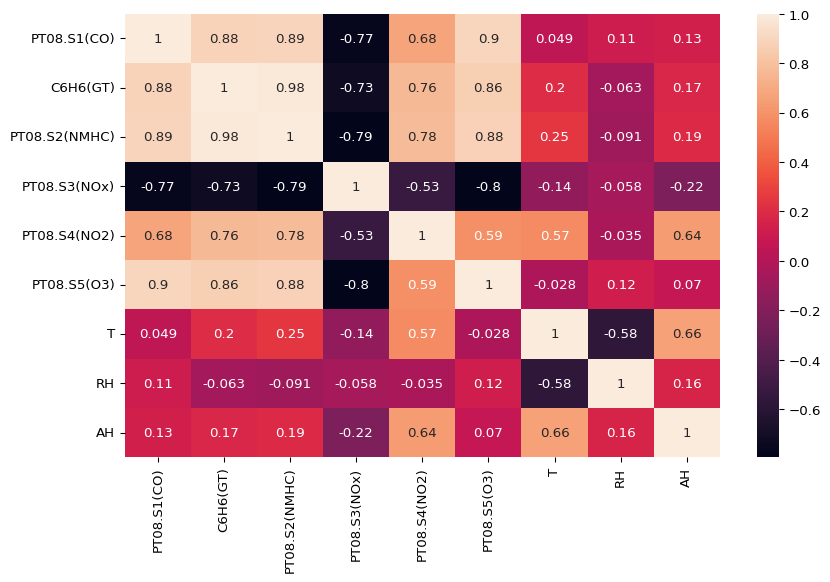

In [3]:
# Heatmap to pinpoint the columns in the 'df' DataFrame exhibiting high correlation.
corr_df = df.iloc[:, 1:-4].corr()
plt.figure(figsize = (10, 6), dpi = 96)
sns.heatmap(data = corr_df, annot = True) # 'annot=True' fills the R values in the heatmap cells.
plt.show()

---

#### Activity 1: Multiple Linear Regression Model Using `sklearn` Module^^

Let's jump right ahead to build a multiple linear regression model using the `sklearn` module. Later, we will also use the `statsmodels` module to build a linear regression model and also to assess whether a feature is useful or in technical terms **significant**.

You will understand this as we progress. For the time being, let's first create a list of features.

In [4]:
# S1.1: Create a list of feature variables.
#print(df.columns)
#print(df.columns.values)
features = list(df.columns.values[1:-1])
features.remove('RH')
features

['PT08.S1(CO)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'PT08.S3(NOx)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'AH',
 'Year',
 'Month',
 'Day']

Now let's build a linear regression model using the `sklearn` module by including all the features listed above.

In [5]:
# S1.2: Build a linear regression model using the sklearn module by including all the features listed above.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[features]
y = df['RH']

# Splitting the DataFrame into the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42) # Test set will have 33% of the values.

y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Build linear regression model using the 'sklearn.linear_model' module.
sklearn_lin_reg = LinearRegression()
sklearn_lin_reg.fit(X_train, y_train_reshaped)

# Print the value of the intercept i.e. beta-sub-0.
print("\nConstant".ljust(15, " "), f"{sklearn_lin_reg.intercept_[0]:.6f}") # Soon you will get to know why rounding-off to 6 decimal places.

# Print the names of the features along with the values of their corresponding coefficients.

for item in list(zip(X.columns.values, sklearn_lin_reg.coef_[0])): #co eff is 2 dimensional hence sklearn_lin_reg.coef_[0]
  print(f"{item[0]}".ljust(15, " "), f"{item[1]:.6f}") # Soon you will get to know why rounding-off to 6 decimal places.


Constant       -15028.451823
PT08.S1(CO)     0.014833
C6H6(GT)        -0.903464
PT08.S2(NMHC)   -0.005881
PT08.S3(NOx)    0.001503
PT08.S4(NO2)    0.026497
PT08.S5(O3)     -0.001066
T               -2.354919
AH              29.551742
Year            7.505153
Month           1.167861
Day             0.035232


As you can see, the coefficients for a few of the features have a very low value and the intercept ($\beta_0$) is very high in comparison. We will analyse the significance of these values as we proceed forward. For the time being, let's compute the $R^2$, MSE, RMSE and MAE values.

In [6]:
# S1.3: Evaluate the linear regression model using the 'r2_score', 'mean_squared_error' & 'mean_absolute_error' functions of the 'sklearn' module.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_train_pred = sklearn_lin_reg.predict(X_train)
y_test_pred = sklearn_lin_reg.predict(X_test)

print(f"Train Set\n{'-' * 50}")
print(f"R-squared: {r2_score(y_train_reshaped, y_train_pred):.3f}")
print(f"Mean Squared Error: {mean_squared_error(y_train_reshaped, y_train_pred):.3f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_train_reshaped, y_train_pred)):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_train_reshaped, y_train_pred):.3f}")

print(f"\n\nTest Set\n{'-' * 50}")
print(f"R-squared: {r2_score(y_test_reshaped, y_test_pred):.3f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reshaped, y_test_pred):.3f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reshaped, y_test_pred)):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reshaped, y_test_pred):.3f}")

Train Set
--------------------------------------------------
R-squared: 0.879
Mean Squared Error: 35.116
Root Mean Squared Error: 5.926
Mean Absolute Error: 4.572


Test Set
--------------------------------------------------
R-squared: 0.879
Mean Squared Error: 34.702
Root Mean Squared Error: 5.891
Mean Absolute Error: 4.564


When we built the linear regression model with only the temperature as the independent variable, the $R^2$ value was 32.46% approximately. Now it has increased to 87.9% because of having more features which is a great improvement as the $R^2$ value should be close to 1. This means the unexplained variance in the regression model is only 12.1%. The MSE, RMSE and MAE values are also not too high.

So by looking at these metrics, we may tend to think that we have built a very good model but how do we make sure. For this, we need to measure the significance of the coefficients of all the features including the constant as well. This is the point where we will use the `statsmodels.api` module in Python.

---

#### Activity 2: The `statsmodels.api` Module^^^

The `statsmodels` module is another Python module that you can use to build a linear regression model and also assess whether a feature is useful or in technical terms **significant**.

Let's create data frames for the features and target again and also split them into train and test sets.

In [7]:
# S2.1: Create data frames for the features and target again and also split them into the train and test sets.
X = df[features]
y = df['RH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42) # Test set will have 33% of the values.

Now to build a linear regression model

- Import the `statsmodels.api` module.

- Call the `add_constant()` function of `statsmodels.api` module. It takes the feature set as an input. It initialises the $\beta_0$ (or constant) with some arbitrary value and then seeks the best value for it through the **ordinary least squares** method which we shall discuss later.

- Create an object of the `OLS` class and call the `fit()` function to build a linear regression model. The constructor of the `OLS` class takes the target and features as inputs (in that order) and builds a linear regression model.

- Finally, use the `params` attribute of the `OLS` class to get the values of all the coefficients.

In [8]:
# T2.1: Build a linear regression model using the 'statsmodels.api' module.
import statsmodels.api as sm

# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the regression line using 'OLS'
sm_lin_reg = sm.OLS(y_train, X_train_sm).fit()

# Print the parameters, i.e. the intercept and the slope of the regression line fitted
sm_lin_reg.params

,0
const,-15028.451823
PT08.S1(CO),0.014833
C6H6(GT),-0.903464
PT08.S2(NMHC),-0.005881
PT08.S3(NOx),0.001503
PT08.S4(NO2),0.026497
PT08.S5(O3),-0.001066
T,-2.354919
AH,29.551742
Year,7.505153


The above values for the constant and the coefficients of all the features are almost the same as the ones obtained through the `sklearn` linear regression model.

In [9]:
# S2.2: Subtract the constant and the coefficient values obtained through 'sklearn' from the ones obtained through 'statsmodels.api'.
print(sm_lin_reg.params.values[0] - sklearn_lin_reg.intercept_[0])
print(sm_lin_reg.params.values[1:] - sklearn_lin_reg.coef_)

5.331567081157118e-07
[[ 6.66949135e-14  1.45941037e-11 -1.68515375e-13 -1.49300928e-13
  -4.58518640e-13 -8.32797373e-15 -4.04121181e-14  1.27432287e-10
  -2.65755418e-10 -2.30606645e-11 -1.19427385e-12]]


As you can see the above values are practically $0$ because their scale is at least $10^{-11}$ or $\frac{1}{10^{11}}$

Now let's print the statistical summary of the regression model that we built to find the significant features based on **p-value**.

In [10]:
# S2.3: Performing a summary operation lists out all the different parameters of the regression line fitted
print(sm_lin_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                     RH   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     4115.
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        16:52:31   Log-Likelihood:                -20050.
No. Observations:                6269   AIC:                         4.012e+04
Df Residuals:                    6257   BIC:                         4.020e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.503e+04   1240.167    -12.118

For a feature to be statistically significant, the p-value should be equal to or less than 0.05. From the above table, `PT08.S3(NOx)` and `PT08.S5(O3)` have the p-values greater than 0.05. Hence, they are statistically insignificant for the regression model created. So you may have to eliminate these features.

Also, read the second warning obtained in the summary. It says `The condition number is large, 5.25e+07. This might indicate that there are strong multicollinearity or other numerical problems.`

So now it is the time to understand three important concepts to make sense of what we have done so far and what the results and the warnings mean. These concepts are:

1. Ordinary Least Squares (OLS)
2. Multicollinearity
3. p-value

Let's stop here and continue in the next class.

---

### Activities

**Teacher Activities**

1. Multiple Linear Regression - Introduction (Class Copy)

   Link on Panel

2. Multiple Linear Regression - Introduction (Reference)

   Link on Panel

---